In [1]:
#Step 1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Step 2: Load the Dataset

# Load your dataset
df = pd.read_csv('drugs_side_effects_drugs_com.csv')

# Display the first few rows of the dataset
df.head()

,drug_name,medical_condition,side_effects,generic_name,drug_classes,brand_names,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,medical_condition_description,rating,no_of_reviews,drug_link,medical_condition_url
0,doxycycline,Acne,"(hives, difficult breathing, swelling in your ...",doxycycline,"Miscellaneous antimalarials, Tetracyclines","Acticlate, Adoxa CK, Adoxa Pak, Adoxa TT, Alod...",87%,Rx,D,N,X,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,6.8,760.0,https://www.drugs.com/doxycycline.html,https://www.drugs.com/condition/acne.html
1,spironolactone,Acne,hives ; difficulty breathing; swelling of your...,spironolactone,"Aldosterone receptor antagonists, Potassium-sp...","Aldactone, CaroSpir",82%,Rx,C,N,X,amlodipine: https://www.drugs.com/amlodipine.h...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.2,449.0,https://www.drugs.com/spironolactone.html,https://www.drugs.com/condition/acne.html
2,minocycline,Acne,"skin rash, fever, swollen glands, flu-like sym...",minocycline,Tetracyclines,"Dynacin, Minocin, Minolira, Solodyn, Ximino, V...",48%,Rx,D,N,NaN,amoxicillin: https://www.drugs.com/amoxicillin...,Acne Other names: Acne Vulgaris; Blackheads; B...,5.7,482.0,https://www.drugs.com/minocycline.html,https://www.drugs.com/condition/acne.html
3,Accutane,Acne,problems with your vision or hearing; muscle o...,isotretinoin (oral),"Miscellaneous antineoplastics, Miscellaneous u...",NaN,41%,Rx,X,N,X,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.9,623.0,https://www.drugs.com/accutane.html,https://www.drugs.com/condition/acne.html
4,clindamycin,Acne,hives ; difficult breathing; swelling of your ...,clindamycin topical,"Topical acne agents, Vaginal anti-infectives","Cleocin T, Clindacin ETZ, Clindacin P, Clindag...",39%,Rx,B,N,NaN,doxycycline: https://www.drugs.com/doxycycline...,Acne Other names: Acne Vulgaris; Blackheads; B...,7.4,146.0,https://www.drugs.com/mtm/clindamycin-topical....,https://www.drugs.com/condition/acne.html


In [3]:
#Step 3: Data Cleaning
## Check for missing values:
# Check for missing values
df.isnull().sum()

##Handle missing values:
# Example: Drop rows with missing values
df_cleaned = df.dropna()

# Or fill missing values with a placeholder
df_filled = df.fillna('Unknown')

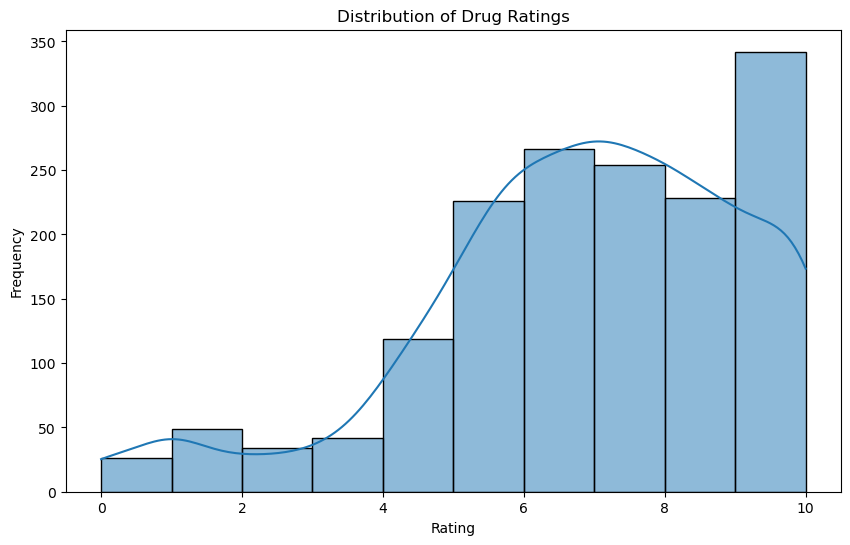

In [4]:
#Step 4: Basic Data Exploration

# Summary statistics
df.describe()

# Distribution of drug ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribution of Drug Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

medical_condition  drug_name    
Acne               minocycline      2
Eczema             fluocinolone     2
Herpes             acyclovir        2
ADHD               Adderall         1
                   Adderall XR      1
                   Mydayis          1
                   Qelbree          1
                   QuilliChew ER    1
                   Quillivant XR    1
                   Relexxii         1
Name: count, dtype: int64
side_effects
hives ; difficult breathing; swelling of your face, lips, tongue, or throat. This medicine may cause serious side effects. Stop using this medicine and call your doctor at once if you have: redness or swelling of the treated area; increased pain; or severe burning or skin irritation such as a rash, itching, pain, or blistering. Less serious side effects may be more likely, and you may have none at all.                                                                                                                                               

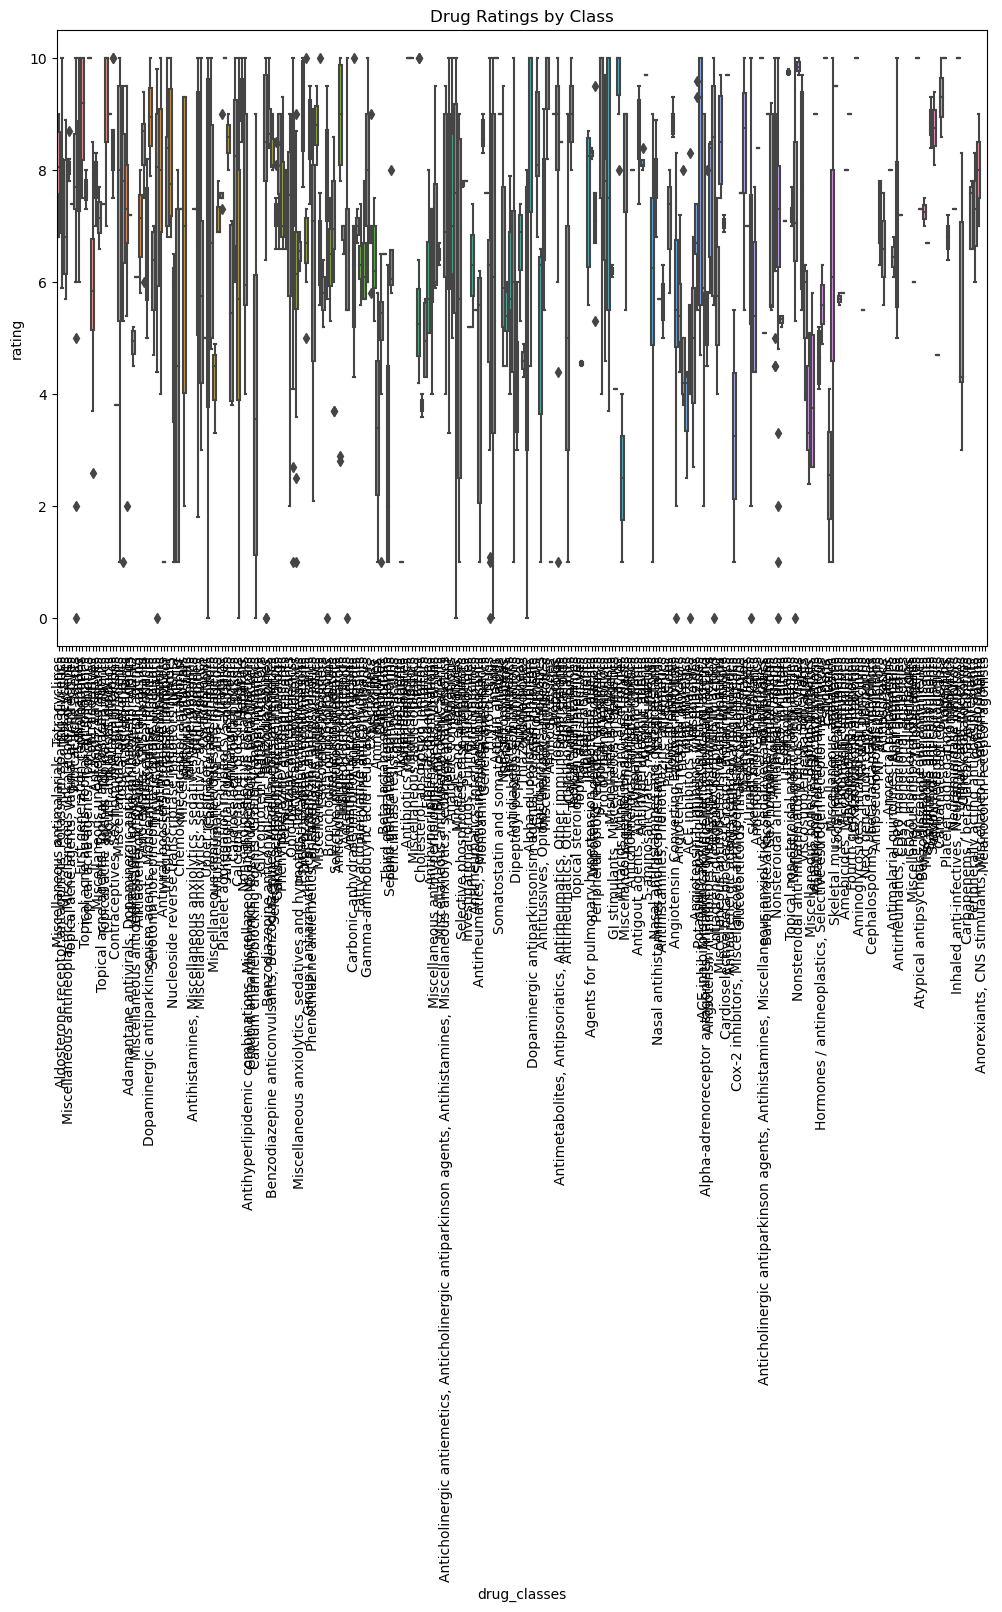

In [6]:
#Step 5: Analyzing Relationships
##Top Drugs by Condition:

# Count the most common drugs for each medical condition
top_drugs =df.groupby('medical_condition')['drug_name'].value_counts().nlargest(10)
print(top_drugs)

##Side Effects Analysis:

# Analyzing the most common side effects
side_effects = df['side_effects'].value_counts().head(10)
print(side_effects)

##Drug Ratings by Class:

# Boxplot of ratings by drug class
plt.figure(figsize=(12, 8))
sns.boxplot(x='drug_classes', y='rating', data=df)
plt.xticks(rotation=90)
plt.title('Drug Ratings by Class')
plt.show()